# Reducción de Dimensionalidad de Datos de Calidad del Aire Usando Autoencoders

Este notebook utiliza autoencoders para reducir la dimensionalidad de los datos de calidad del aire de la red RAMA en la Ciudad de México. Analizamos datos de tres estaciones (BJU, UAX, MER) y tres contaminantes (CO, O3, NO2) durante el período 2020-2024.

Autor: Thanos Drossos

## Resumen

1. Importar y preprocesar datos de archivos XLS (similar a AirQuality.ipynb)
2. Crear un conjunto de datos con 9 características (3 contaminantes × 3 estaciones)
3. Implementar un autoencoder usando TensorFlow/Keras para reducir dimensiones a 2D
4. Visualizar los resultados en un gráfico 2D

Este enfoque nos permite identificar patrones y relaciones en los datos que podrían no ser evidentes en el espacio original de 9 dimensiones.

# Resultados y Conlclusiones

En este notebook, utilizamos un autoencoder para reducir la dimensionalidad de los datos de calidad del aire de 9 características (3 contaminantes × 3 estaciones) a 2 dimensiones. La visualización de los datos codificados revela patrones relacionados con el tiempo (año y mes) que podrían ser difíciles de identificar en el espacio original de alta dimensionalidad.

## Hallazgos principales después de la reducción de dimensiones:
1. Patrones temporales evidentes: Se observan claros patrones temporales al comparar por año y por mes, sugiriendo ciclos estacionales en la contaminación del aire.

2. Homogeneidad entre estaciones: No se aprecian diferencias significativas entre las estaciones en el espacio 2D, a pesar de que los datos originales difieren en magnitud. Esto sugiere que los patrones de contaminación son similares entre estaciones, aunque con diferentes intensidades.

3. Error de reconstrucción por contaminante: El CO de las tres estaciones presenta el mayor error de reconstrucción, lo que significa que este contaminante es el menos bien representado en el espacio 2D y posiblemente tiene comportamientos más complejos o independientes que no pueden capturarse completamente en solo dos dimensiones.

4. Diferencias geográficas: Las estaciones de UAX (Xochimilco), ubicadas en la periferia, muestran un error de reconstrucción aumentado en comparación con las otras dos estaciones más céntricas (Benito Juárez y Merced). Esto sugiere que la dinámica de contaminación en zonas periféricas podría ser más compleja.

5. Correlaciones diferenciales: Los datos de O₃ son muy diferentes a los de NO₂ y CO en términos de correlación con las dimensiones codificadas. Esto refleja la naturaleza distinta del ozono como contaminante secundario, formado por reacciones fotoquímicas.

6. Agrupación por tipo de contaminante: Al visualizar por contaminante, se observa claramente la similitud entre NO₂ y CO (contaminantes primarios relacionados con combustión), mientras que el O₃ aparece aislado, confirmando su comportamiento diferenciado.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# Para autoencoders
import tensorflow as tf
from tensorflow import keras

model = keras.models.Model
sequential = keras.models.Sequential
dense = keras.layers.Dense
input_layer = keras.layers.Input
activation = keras.layers.Activation

np.random.seed(69)
tf.random.set_seed(69)

## 1. Carga y Preprocesamiento de Datos

Primero, cargaremos y preprocesaremos los datos de calidad del aire de los archivos XLS siguiendo el mismo enfoque que en AirQuality.ipynb.

In [ ]:
contaminants = ['CO', 'O3', 'NO2']
years = range(2020, 2025) 
stations = ['BJU', 'UAX', 'MER']

data_dir = 'RAMA'

data_by_contaminant = {contaminant: {} for contaminant in contaminants}

for contaminant in contaminants:
    dfs = []
    for year in years:
        filename = os.path.join(data_dir, f"{year}{contaminant}.xls")
        if os.path.exists(filename):
            print(f"Procesando {filename}")
            try:
                df = pd.read_excel(filename)
                
                # Filtrar solo las estaciones requeridas
                station_columns = [col for col in df.columns if col in stations]
                if not station_columns:
                    print(f"No se encontraron estaciones requeridas en {filename}")
                    continue
                
                columns_to_keep = ['FECHA', 'HORA'] + station_columns
                df = df[columns_to_keep]
                
                df = df.replace(-99, np.nan)
                
                df['YEAR'] = year
                dfs.append(df)
            except Exception as e:
                print(f"Error al procesar {filename}: {e}")
    
    if dfs:
        # Combinar todos los datos para este contaminante
        combined_df = pd.concat(dfs, ignore_index=True)
        
        combined_df['DATETIME'] = pd.to_datetime(combined_df['FECHA'], format='%d.%m.%Y', errors='coerce')
        combined_df['DATE'] = combined_df['DATETIME'].dt.date
        
        data_by_contaminant[contaminant] = combined_df
    else:
        print(f"No se encontraron datos para {contaminant}")

Procesando RAMA\2020CO.xls
Procesando RAMA\2021CO.xls
Procesando RAMA\2022CO.xls
Procesando RAMA\2023CO.xls
Procesando RAMA\2024CO.xls
Procesando RAMA\2020O3.xls
Procesando RAMA\2021O3.xls
Procesando RAMA\2022O3.xls
Procesando RAMA\2023O3.xls
Procesando RAMA\2024O3.xls
Procesando RAMA\2020NO2.xls
Procesando RAMA\2021NO2.xls
Procesando RAMA\2022NO2.xls
Procesando RAMA\2023NO2.xls
Procesando RAMA\2024NO2.xls


## 2. Calcular Promedios Diarios y Crear Conjunto de Datos Combinado

A continuación, calcularemos promedios diarios para cada estación y contaminante, y luego los combinaremos en un único conjunto de datos para el autoencoder.

In [3]:
daily_avg_by_contaminant = {}

for contaminant, df in data_by_contaminant.items():
    if not df.empty:
        daily_avg = df.groupby('DATE')[stations].mean()
        daily_avg_by_contaminant[contaminant] = daily_avg
        
        print(f"Promedios diarios para {contaminant}:")
        print(daily_avg.head())

combined_daily = pd.DataFrame()

for contaminant, daily_avg in daily_avg_by_contaminant.items():
    for station in stations:
        if station in daily_avg.columns:
            col_name = f"{contaminant}_{station}"
            combined_daily[col_name] = daily_avg[station]

print("\nConjunto de datos combinado:")
print(combined_daily.head())
print(f"\nDimensiones del conjunto de datos: {combined_daily.shape}")

Promedios diarios para CO:
                 BJU       UAX       MER
DATE                                    
2020-01-01  0.458333       NaN  0.630435
2020-01-02  0.128571       NaN  0.242857
2020-01-03  0.270833       NaN  0.491667
2020-01-04  0.304167  0.295833  0.454167
2020-01-05  0.520833  0.445833  0.391667
Promedios diarios para O3:
                  BJU        UAX        MER
DATE                                       
2020-01-01  16.521739  23.652174  18.086957
2020-01-02  16.047619  21.666667  15.285714
2020-01-03  21.375000  27.454545  19.250000
2020-01-04  23.764706  28.750000  21.666667
2020-01-05        NaN  28.541667  24.916667
Promedios diarios para NO2:
                  BJU        UAX        MER
DATE                                       
2020-01-01  16.086957   9.000000  16.521739
2020-01-02   9.190476   3.904762  12.761905
2020-01-03  22.583333  12.100000  29.541667
2020-01-04  28.833333        NaN  37.791667
2020-01-05  36.166667        NaN  42.166667

Conjunto de da

## 3. Preparar Datos para el Autoencoder

Necesitamos preparar los datos para el autoencoder mediante:
1. Manejo de valores faltantes
2. Estandarización de las características
3. Creación de conjuntos de entrenamiento y prueba

In [4]:
combined_daily_cleaned = combined_daily.dropna()
print(f"Dimensiones después de eliminar filas con valores faltantes: {combined_daily_cleaned.shape}")

# Estandarizar los datos (media=0, desv=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined_daily_cleaned)

# Dividir datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
train_size = int(0.8 * len(scaled_data))
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Dimensiones de datos de entrenamiento: {train_data.shape}")
print(f"Dimensiones de datos de prueba: {test_data.shape}")

Dimensiones después de eliminar filas con valores faltantes: (1197, 9)
Dimensiones de datos de entrenamiento: (957, 9)
Dimensiones de datos de prueba: (240, 9)


## 4. Construir y Entrenar el Autoencoder

Ahora construiremos una red neuronal de autoencoder para reducir la dimensionalidad de nuestros datos de 9 características a 2 dimensiones.

In [5]:
input_dim = train_data.shape[1]  # Debería ser 9 (3 contaminantes × 3 estaciones)

input_data = input_layer(shape=(input_dim,))

encoder = dense(6)(input_data)
encoder = activation('relu')(encoder)

encoder = dense(4)(encoder)
encoder = activation('relu')(encoder)

encoded = dense(2, name='bottleneck')(encoder)

decoder = dense(4)(encoded)
decoder = activation('relu')(decoder)

decoder = dense(6)(decoder)
decoder = activation('relu')(decoder)

decoded = dense(input_dim)(decoder)

autoencoder = model(inputs=input_data, outputs=decoded)
autoencoder.compile(loss='mse', optimizer='adam')

autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 9)]               0         
                                                                 
 dense (Dense)               (None, 6)                 60        
                                                                 
 activation (Activation)     (None, 6)                 0         
                                                                 
 dense_1 (Dense)             (None, 4)                 28        
                                                                 
 activation_1 (Activation)   (None, 4)                 0         
                                                                 
 bottleneck (Dense)          (None, 2)                 10        
                                                                 
 dense_2 (Dense)             (None, 4)                 12    

In [6]:
history = autoencoder.fit(
    train_data, train_data,  # Entrada = Salida
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_data=(test_data, test_data),
    verbose=1
)

Epoch 1/100
30/30 [==============================] - 1s 8ms/step - loss: 0.9295 - val_loss: 1.2876
Epoch 2/100
30/30 [==============================] - 0s 2ms/step - loss: 0.9128 - val_loss: 1.2828
Epoch 3/100
30/30 [==============================] - 0s 2ms/step - loss: 0.8932 - val_loss: 1.2735
Epoch 4/100
30/30 [==============================] - 0s 2ms/step - loss: 0.8616 - val_loss: 1.2611
Epoch 5/100
30/30 [==============================] - 0s 2ms/step - loss: 0.8305 - val_loss: 1.2465
Epoch 6/100
30/30 [==============================] - 0s 2ms/step - loss: 0.7977 - val_loss: 1.2217
Epoch 7/100
30/30 [==============================] - 0s 2ms/step - loss: 0.7515 - val_loss: 1.1811
Epoch 8/100
30/30 [==============================] - 0s 2ms/step - loss: 0.6908 - val_loss: 1.1290
Epoch 9/100
30/30 [==============================] - 0s 2ms/step - loss: 0.6322 - val_loss: 1.0765
Epoch 10/100
30/30 [==============================] - 0s 3ms/step - loss: 0.5705 - val_loss: 1.0058
Epoch 11/

## 5. Visualizar Historial de Entrenamiento

Visualicemos el error de entrenamiento y validación para ver qué tan bien se entrenó nuestro modelo.

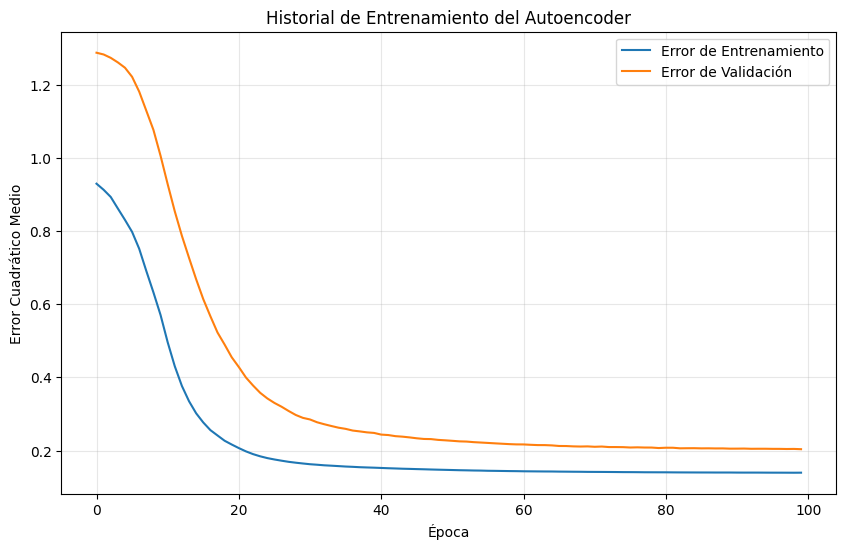

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error de Entrenamiento')
plt.plot(history.history['val_loss'], label='Error de Validación')
plt.title('Historial de Entrenamiento del Autoencoder')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Extraer y Visualizar la Representación Codificada (2D)

Ahora crearemos un modelo codificador separado para extraer la representación 2D de nuestros datos y visualizarla.

In [8]:
# Crear un modelo codificador para obtener la representación 2D
encoder_model = model(inputs=autoencoder.input, outputs=autoencoder.get_layer('bottleneck').output)

encoded_data = encoder_model.predict(scaled_data)

encoded_df = pd.DataFrame()
encoded_df['x'] = encoded_data[:, 0]
encoded_df['y'] = encoded_data[:, 1]

# Añadir información de fecha del conjunto de datos original
encoded_df['date'] = combined_daily_cleaned.index
encoded_df['year'] = pd.to_datetime(encoded_df['date']).dt.year
encoded_df['month'] = pd.to_datetime(encoded_df['date']).dt.month

# Mostrar las primeras filas
print(encoded_df.head())

38/38 [==============================] - 0s 676us/step
          x         y        date  year  month
0  2.896959 -2.848228  2020-01-18  2020      1
1  3.919591 -6.152839  2020-01-19  2020      1
2  5.205566 -5.471696  2020-01-20  2020      1
3  5.719744 -3.040446  2020-01-21  2020      1
4  3.517109 -1.753743  2020-01-22  2020      1


## 7. Visualizar la Representación 2D por Año

Vamos a crear un gráfico de dispersión de la representación 2D, coloreando los puntos por año para ver si hay patrones temporales.

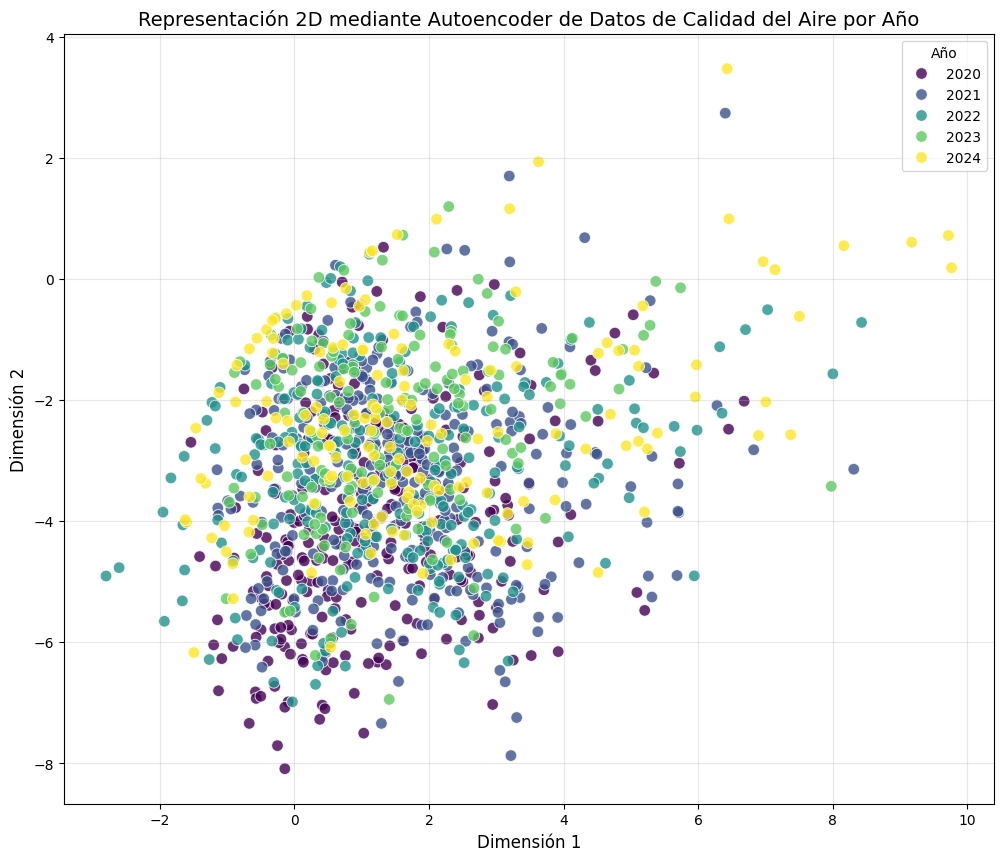

In [9]:
# Crear un gráfico de dispersión con puntos coloreados por año
plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', hue='year', palette='viridis', data=encoded_df, alpha=0.8, s=70)
plt.title('Representación 2D mediante Autoencoder de Datos de Calidad del Aire por Año', fontsize=14)
plt.xlabel('Dimensión 1', fontsize=12)
plt.ylabel('Dimensión 2', fontsize=12)
plt.legend(title='Año', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Visualizar la Representación 2D por Mes

Ahora vamos a colorear los puntos por mes para identificar patrones estacionales.

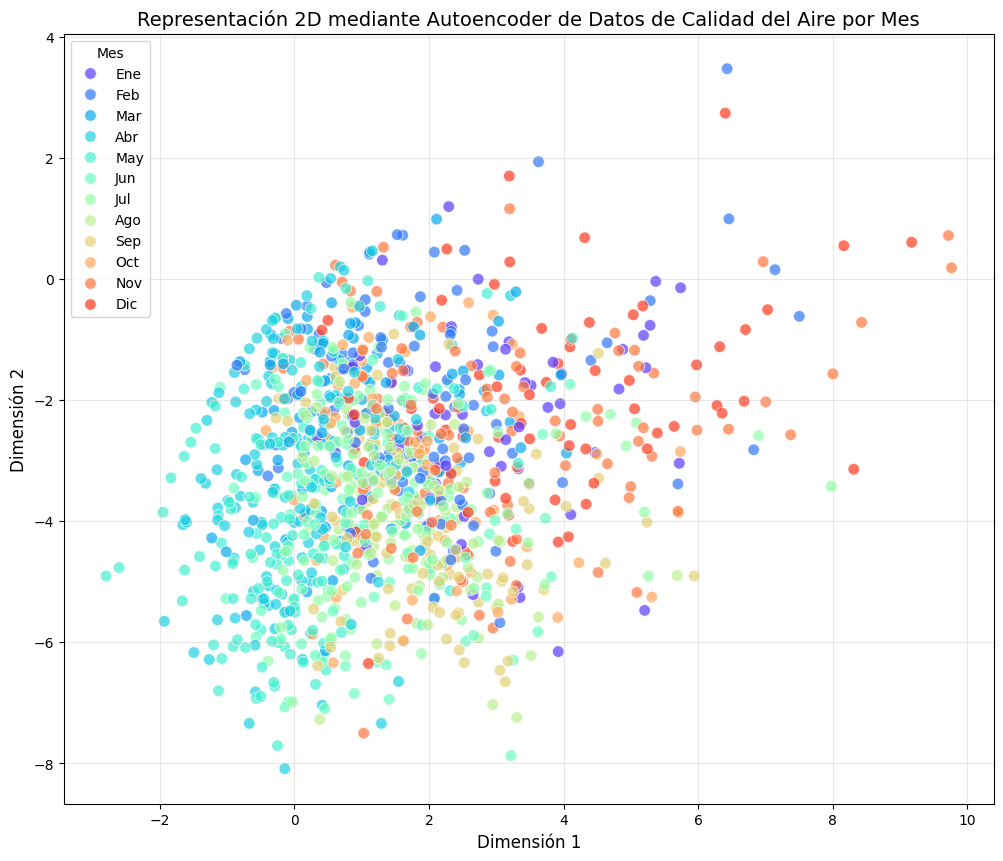

In [10]:
month_names = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
encoded_df['month_name'] = encoded_df['month'].map(month_names)

plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', hue='month_name', palette='rainbow', data=encoded_df, alpha=0.7, s=70)
plt.title('Representación 2D mediante Autoencoder de Datos de Calidad del Aire por Mes', fontsize=14)
plt.xlabel('Dimensión 1', fontsize=12)
plt.ylabel('Dimensión 2', fontsize=12)
plt.legend(title='Mes', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 9. Analizar la Importancia de las Características mediante Reconstrucción Individual

Podemos analizar qué características son más importantes en la representación 2D observando el error de reconstrucción para cada característica.

38/38 [==============================] - 0s 825us/step


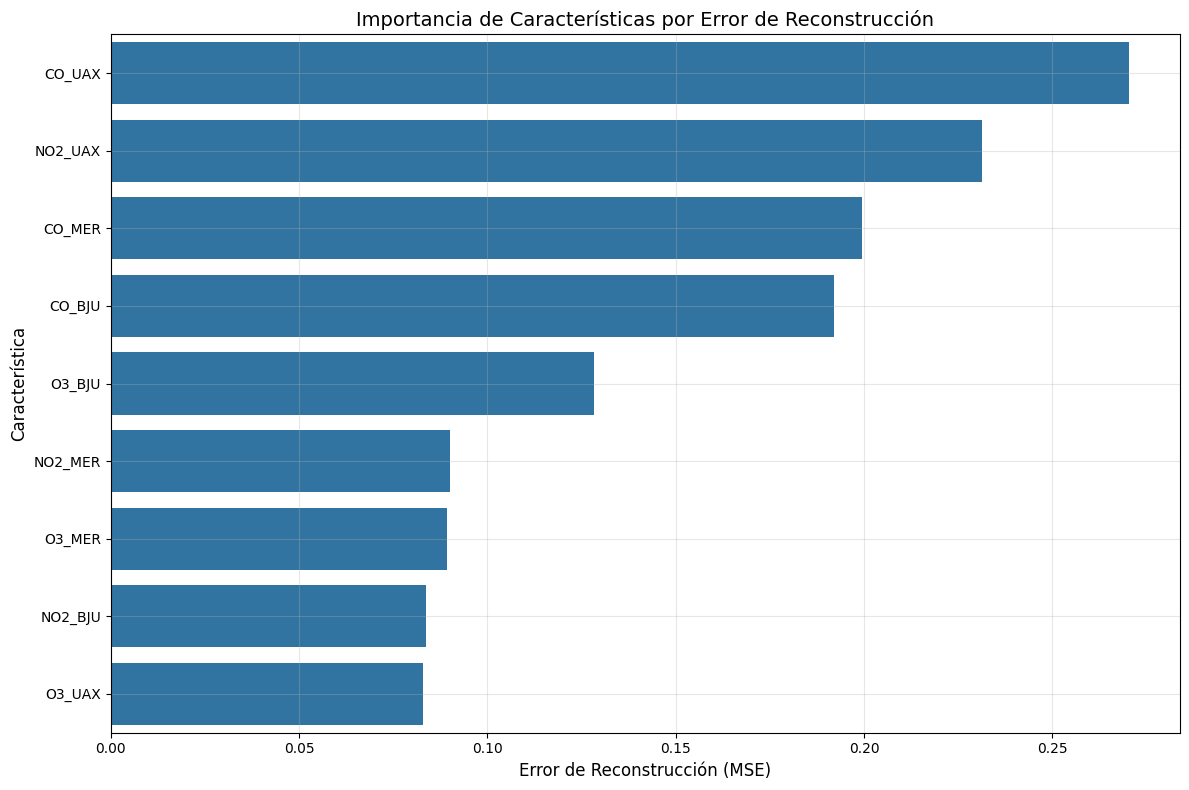

In [ ]:
reconstructed_data = autoencoder.predict(scaled_data)

reconstruction_errors = np.mean(np.square(scaled_data - reconstructed_data), axis=0)

# Crear un df con nombres de características y errores de reconstrucción
feature_importance = pd.DataFrame({
    'Feature': combined_daily_cleaned.columns,
    'Reconstruction Error': reconstruction_errors
})

# Ordenar por error de reconstrucción (mayor error = menos bien representada en el espacio 2D)
feature_importance = feature_importance.sort_values('Reconstruction Error', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Reconstruction Error', y='Feature', data=feature_importance)
plt.title('Importancia de Características por Error de Reconstrucción', fontsize=14)
plt.xlabel('Error de Reconstrucción (MSE)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Análisis de Correlación de Características Originales con Dimensiones 2D

Examinemos qué características originales se correlacionan con cada dimensión en nuestra representación 2D.

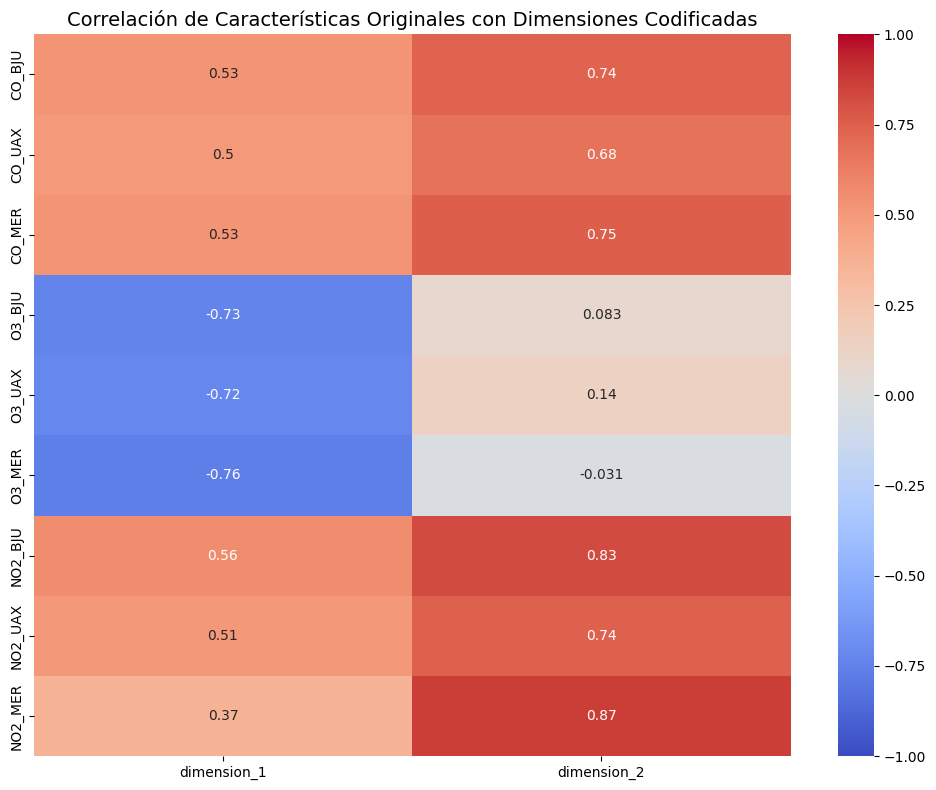

C:\Users\thano\AppData\Local\Temp\ipykernel_8184\791724801.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (correlations['dimension_1'][i], correlations['dimension_2'][i]), fontsize=10)


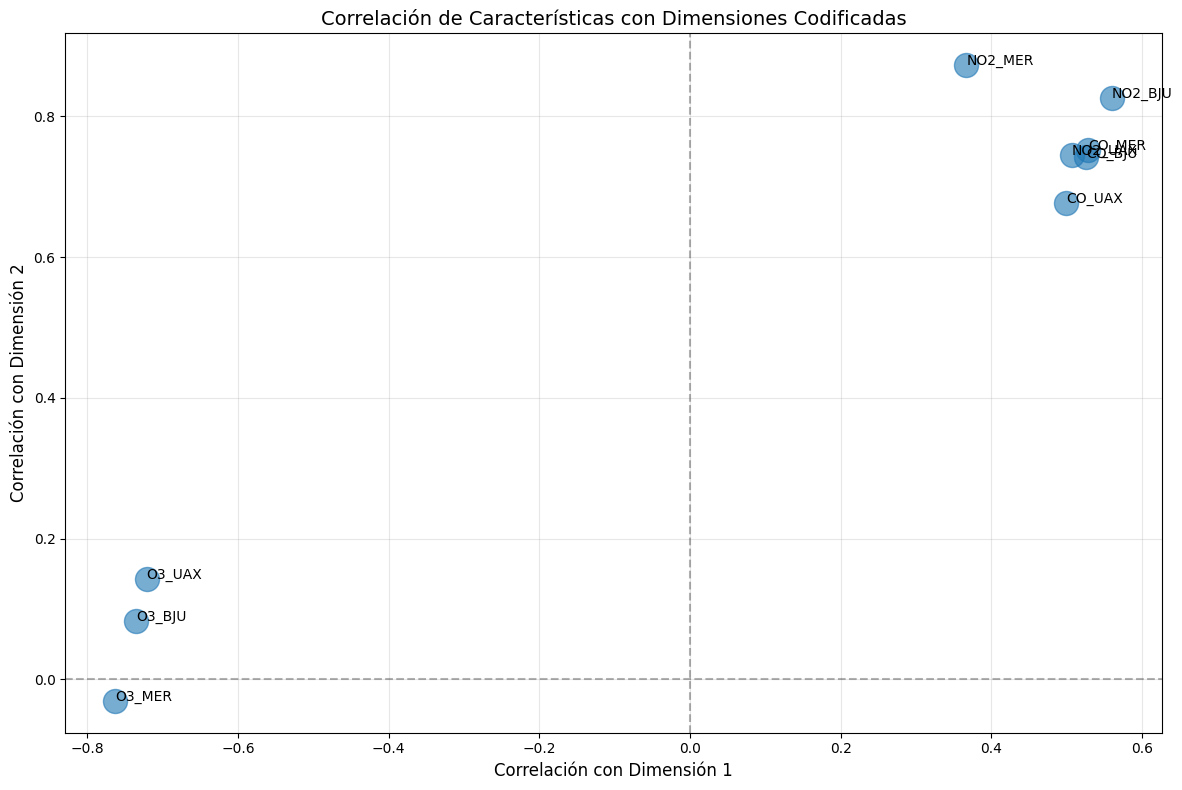

In [ ]:
correlation_df = pd.DataFrame(scaled_data, columns=combined_daily_cleaned.columns)
correlation_df['dimension_1'] = encoded_data[:, 0]
correlation_df['dimension_2'] = encoded_data[:, 1]

# Calcular correlación de características originales con dimensiones codificadas
correlations = correlation_df.corr()[['dimension_1', 'dimension_2']].iloc[:-2]

plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Características Originales con Dimensiones Codificadas', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.scatter(
    correlations['dimension_1'],
    correlations['dimension_2'],
    s=300,
    alpha=0.6
)

for i, txt in enumerate(correlations.index):
    plt.annotate(txt, (correlations['dimension_1'][i], correlations['dimension_2'][i]), fontsize=10)
    
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.title('Correlación de Características con Dimensiones Codificadas', fontsize=14)
plt.xlabel('Correlación con Dimensión 1', fontsize=12)
plt.ylabel('Correlación con Dimensión 2', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Visualizacion por estación 

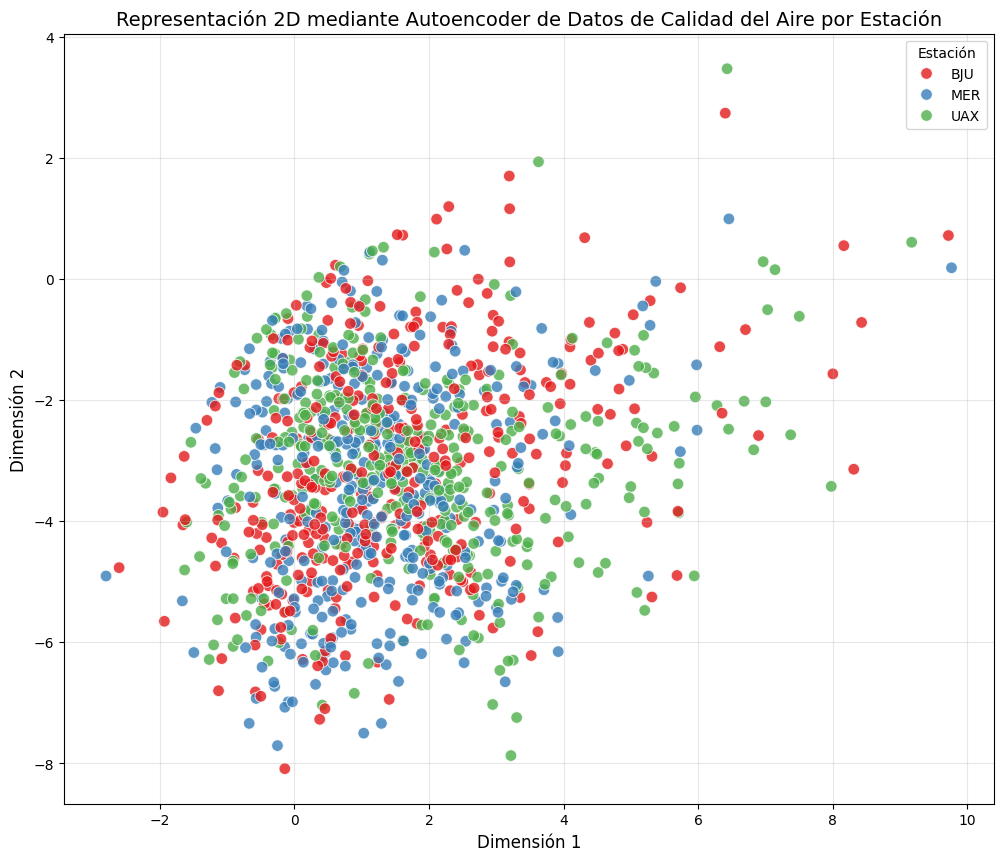

In [ ]:
correlation_matrix = correlation_df.corr()[['dimension_1', 'dimension_2']].iloc[:-2]

stations = ['BJU', 'UAX', 'MER']
station_map = {}

for i, row in encoded_df.iterrows():
    max_correlation = -1
    dominant_station = None
    
    for station in stations:
        station_columns = [col for col in correlation_df.columns if station in col and col not in ['dimension_1', 'dimension_2']]
        
        station_influence = 0
        for col in station_columns:
            if col in correlation_df.columns:
                station_influence += abs(correlation_df.loc[i, col]) * (
                    abs(correlation_matrix.loc[col, 'dimension_1']) * abs(row['x']) +
                    abs(correlation_matrix.loc[col, 'dimension_2']) * abs(row['y'])
                )
        
        if station_influence > max_correlation:
            max_correlation = station_influence
            dominant_station = station
    
    station_map[i] = dominant_station

encoded_df['station'] = encoded_df.index.map(lambda x: station_map.get(x, 'Unknown'))

plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', hue='station', palette='Set1', data=encoded_df, alpha=0.8, s=70)
plt.title('Representación 2D mediante Autoencoder de Datos de Calidad del Aire por Estación', fontsize=14)
plt.xlabel('Dimensión 1', fontsize=12)
plt.ylabel('Dimensión 2', fontsize=12)
plt.legend(title='Estación', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 12. Visualización por contaminante

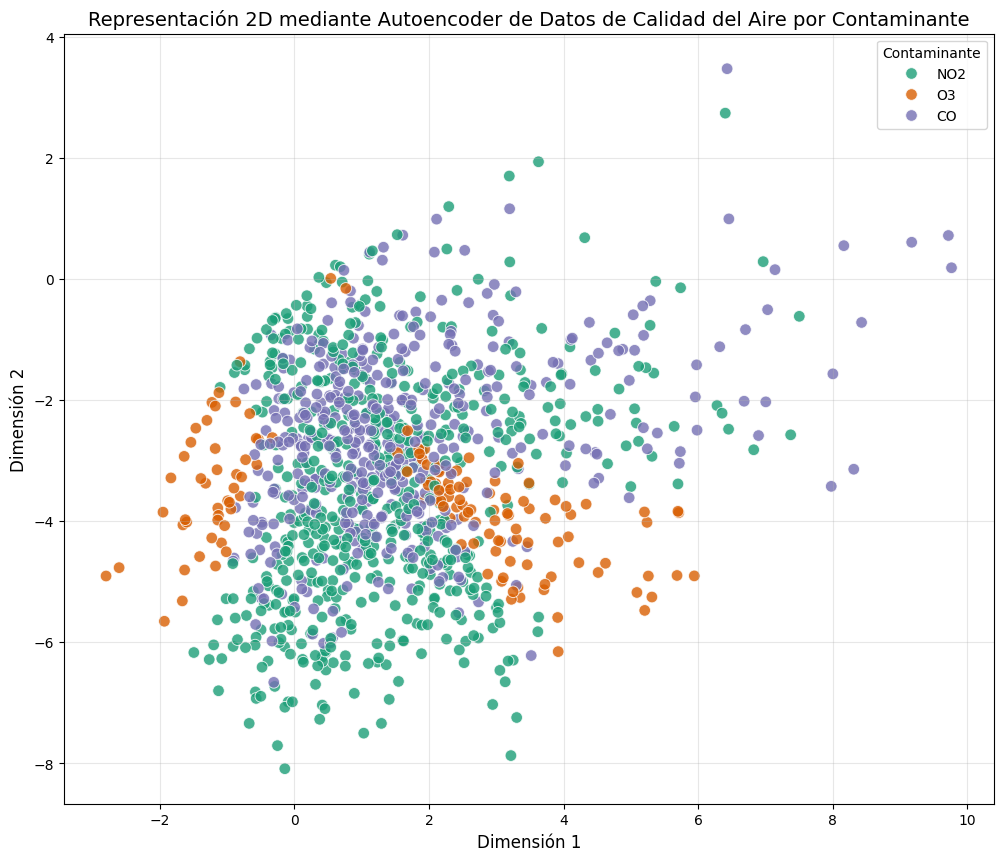

In [15]:
# Visualización por tipo de contaminante
contaminants = ['CO', 'O3', 'NO2']
contaminant_map = {}

# Calcular cuál contaminante tiene mayor influencia en cada punto
for i, row in encoded_df.iterrows():
    max_correlation = -1
    dominant_contaminant = None
    
    for contaminant in contaminants:
        # Obtener columnas relacionadas con este contaminante
        contaminant_columns = [col for col in correlation_df.columns if col.startswith(contaminant) and col not in ['dimension_1', 'dimension_2']]
        
        # Calcular la "influencia del contaminante" usando coordenadas y correlaciones
        contaminant_influence = 0
        for col in contaminant_columns:
            if col in correlation_df.columns:
                contaminant_influence += abs(correlation_df.loc[i, col]) * (
                    abs(correlation_matrix.loc[col, 'dimension_1']) * abs(row['x']) +
                    abs(correlation_matrix.loc[col, 'dimension_2']) * abs(row['y'])
                )
        
        if contaminant_influence > max_correlation:
            max_correlation = contaminant_influence
            dominant_contaminant = contaminant
    
    contaminant_map[i] = dominant_contaminant

# Añadir la información de contaminante al dataframe
encoded_df['contaminant'] = encoded_df.index.map(lambda x: contaminant_map.get(x, 'Unknown'))

# Crear un gráfico de dispersión con puntos coloreados por contaminante
plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', hue='contaminant', palette='Dark2', data=encoded_df, alpha=0.8, s=70)
plt.title('Representación 2D mediante Autoencoder de Datos de Calidad del Aire por Contaminante', fontsize=14)
plt.xlabel('Dimensión 1', fontsize=12)
plt.ylabel('Dimensión 2', fontsize=12)
plt.legend(title='Contaminante', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 13. Guardar el Modelo Codificador y los Datos Codificados

Finalmente, guardemos nuestro modelo codificador y los datos codificados para uso futuro.

In [ ]:
encoder_model.save('air_quality_encoder_model')
print("Modelo codificador guardado.")

encoded_df.to_csv('air_quality_encoded_data.csv', index=False)
print("Datos codificados guardados en CSV.")

INFO:tensorflow:Assets written to: air_quality_encoder_model\assets
Modelo codificador guardado.
Datos codificados guardados en CSV.
